# Sign Language Training - Optimized Program

此版本是可執行程式模板（非純說明）：
- GRU/LSTM 單一入口切換
- **自動偵測訓練模式**（fresh / resume / expand 增量訓練）
- StratifiedShuffleSplit 分層切分
- 資料清洗（NaN/Inf 移除）
- 資料增強（scale / translation / noise / time-warp 5×）
- LR scheduler + EarlyStopping + ModelCheckpoint
- Per-class 評估 + 混淆矩陣
- TFLite 轉換與測試

## 執行順序與前置條件

建議由上到下執行：
1. 第 2 格：載入套件與全域參數
2. 第 3 格：資料讀取 → 清洗 → 模式偵測 → 分割 → 資料增強
3. 第 4 格：建立/載入模型並訓練（自動偵測 fresh/resume/expand）
4. 第 5 格：評估、匯出 SavedModel/TFLite、快速推論測試
5. 第 6 格：可選的 5-fold 交叉驗證

執行前請確認：
- 目前工作目錄是 `cv_hands`
- 已安裝 TensorFlow、scikit-learn、seaborn
- `Words-Dataset` 與 `Word-Label` 資料夾存在

**訓練模式自動偵測**：
- 若 `model/keypoint_classifier/keypoint_sequence_classifier.keras` 不存在 → `fresh` 從零訓練
- 若存在且類別數相同 → `resume` 繼續微調
- 若存在且類別數增加 → `expand` 增量學習（新類別 + replay 舊類別）

In [1]:
import glob
import platform
import random
import subprocess
import sys
from pathlib import Path

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ModuleNotFoundError:
        pkg = pip_name or import_name
        print(f"Installing missing package: {pkg}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        return __import__(import_name)

np = ensure_package('numpy')
tf = ensure_package('tensorflow')
matplotlib = ensure_package('matplotlib')
plt = __import__('matplotlib.pyplot', fromlist=['pyplot'])
sns = ensure_package('seaborn')

sklearn_model_selection = __import__('sklearn.model_selection', fromlist=['train_test_split'])
sklearn_metrics = __import__('sklearn.metrics', fromlist=['classification_report', 'confusion_matrix'])
train_test_split = sklearn_model_selection.train_test_split
classification_report = sklearn_metrics.classification_report
confusion_matrix = sklearn_metrics.confusion_matrix

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'Words-Dataset'
LABEL_CSV = PROJECT_ROOT / 'Word-Label' / 'keypoint_sequence_classifier_label.csv'
SAVE_DIR = PROJECT_ROOT / 'model' / 'keypoint_classifier'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TYPE = 'GRU'  # or 'LSTM'
RANDOM_SEED = 42
SEQUENCE_LENGTH = 25
FEATURES_PER_FRAME = 80
TRAIN_SIZE = 0.75
BATCH_SIZE = 256
EPOCHS = 1000
USE_STREAMING = False  # True: tf.data 串流, False: 直接 numpy 訓練

# ── 增量訓練設定 ──
MODEL_SAVE_PATH = SAVE_DIR / 'keypoint_sequence_classifier.keras'
BEST_WEIGHTS_PATH = SAVE_DIR / 'keypoint_sequence_classifier.best.weights.h5'
SAVED_MODEL_DIR = SAVE_DIR / 'keypoint_sequence_classifier_savedmodel'
TFLITE_SAVE_PATH = SAVE_DIR / 'keypoint_sequence_classifier.tflite'
REPLAY_PER_OLD_CLASS = 20   # expand 模式中每個舊類別的 replay 樣本數
WARMUP_EPOCHS = 5           # expand 模式的分類頭預熱輪數

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow:', tf.__version__)
print('Keras:', getattr(tf.keras, '__version__', 'unknown'))
print('Data dir exists:', DATA_DIR.exists())
print('Label file exists:', LABEL_CSV.exists())
print('Model save path:', MODEL_SAVE_PATH)
print('Best weights path:', BEST_WEIGHTS_PATH)
print('Existing model found:', MODEL_SAVE_PATH.exists())
print('USE_STREAMING:', USE_STREAMING)

TensorFlow: 2.10.1
Keras: 2.10.0
Data dir exists: True
Label file exists: True
Model save path: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras
Best weights path: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.best.weights.h5
Existing model found: True
USE_STREAMING: False


## 第 3 格在做什麼？（資料處理 + 模式偵測）

這一格會完成資料前處理主流程：
- 啟用 GPU 記憶體成長模式（若有 GPU）
- 載入標籤與序列資料
- `sanitize_dataset()`：移除 NaN/Inf 與超範圍標籤
- 偵測訓練模式（fresh / resume / expand）
- expand 模式下：`build_incremental_subset()` 組合新類別 + 舊類別 replay
- 使用 `StratifiedShuffleSplit` 做分層切分（失敗時 fallback 隨機切分）
- 對訓練集做資料增強（scale / translation / noise / time-warp 5×）

如果這格報錯，通常是：
- `FEATURES_PER_FRAME` 與資料實際維度不一致
- 某些 CSV 檔案欄位數異常
- 標籤檔與資料集不對應

In [2]:
import csv
import os
import re


# ══════════════════════════════════════════════
#  GPU / 標籤 / 資料載入
# ══════════════════════════════════════════════

def setup_gpu():
    """設定 CUDA/cuDNN DLL 路徑並啟用 GPU memory growth。"""
    CUDA_BIN = Path(r"C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.5/bin")
    CUDNN_BIN_CANDIDATES = [
        Path.cwd() / "third_party" / "cudnn-8.9.7-cuda11" / "bin",
        Path.cwd() / "cv_hands" / "third_party" / "cudnn-8.9.7-cuda11" / "bin",
    ]

    dll_paths = []
    if CUDA_BIN.exists():
        dll_paths.append(str(CUDA_BIN))
    for candidate in CUDNN_BIN_CANDIDATES:
        if candidate.exists():
            dll_paths.append(str(candidate))
            break
    if dll_paths:
        os.environ["PATH"] = ";".join(dll_paths + [os.environ.get("PATH", "")])
        print("DLL search paths:", dll_paths)

    gpus = tf.config.list_physical_devices('GPU')
    if not gpus:
        print('No GPU detected, using CPU.')
        return
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('GPU ready:', gpus)


def load_labels(path):
    """讀取標籤 CSV（自動處理 UTF-8 BOM）。"""
    with open(path, 'r', encoding='utf-8-sig') as f:
        reader = csv.reader(f)
        return [row[0] for row in reader if row]


def infer_label_from_filename(file_path):
    """從檔名推斷類別，例如 001_sequence.csv -> 1。"""
    stem = Path(file_path).stem
    match = re.match(r'^(\d+)_sequence$', stem)
    if not match:
        return None
    return int(match.group(1))


def load_dataset(data_dir, seq_len, feat_dim):
    files = sorted(glob.glob(str(data_dir / '*_sequence.csv')))
    if not files:
        raise FileNotFoundError('No *_sequence.csv files found.')

    X_list, y_list = [], []
    expected_cols = 1 + seq_len * feat_dim

    for file_path in files:
        arr = np.loadtxt(file_path, delimiter=',', dtype=np.float32)
        arr = np.atleast_2d(arr)
        if arr.shape[1] != expected_cols:
            raise ValueError(f'Column mismatch in {file_path}: {arr.shape[1]} != {expected_cols}')

        inferred = infer_label_from_filename(file_path)
        if inferred is not None:
            y = np.full((arr.shape[0],), inferred, dtype=np.int32)
        else:
            y = arr[:, 0].astype(np.int32)
            print(f'Warning: fallback to first-column labels for {Path(file_path).name}')

        X = arr[:, 1:].reshape(-1, seq_len, feat_dim).astype(np.float32)
        X_list.append(X)
        y_list.append(y)

    X_dataset = np.concatenate(X_list, axis=0)
    y_dataset = np.concatenate(y_list, axis=0)
    return X_dataset, y_dataset


def normalize_labels(y, num_classes):
    """支援 1-based 或 0-based，最終統一 0-based。"""
    if y.min() == 1:
        y = y - 1
    if y.min() < 0 or y.max() >= num_classes:
        raise ValueError(
            f'Label out of range after normalization: min={y.min()}, max={y.max()}, classes={num_classes}. '
            '請確認檔名是否為 001_sequence.csv 這種格式，或檢查標籤檔與資料集是否一致。'
        )
    return y.astype(np.int32)


# ══════════════════════════════════════════════
#  資料清洗 / 增強 / 權重
# ══════════════════════════════════════════════

def sanitize_dataset(X, y, num_classes):
    """移除 NaN/Inf 與超範圍標籤的樣本。"""
    finite_mask = np.isfinite(X).all(axis=(1, 2))
    removed_non_finite = int((~finite_mask).sum())
    if removed_non_finite > 0:
        print(f'Removed non-finite samples: {removed_non_finite}')
    X, y = X[finite_mask], y[finite_mask]
    X = np.nan_to_num(X, nan=0.0, posinf=1e3, neginf=-1e3).astype('float32')

    valid_label_mask = (y >= 0) & (y < num_classes)
    removed_invalid = int((~valid_label_mask).sum())
    if removed_invalid > 0:
        print(f'Removed invalid-label samples: {removed_invalid}')
    X, y = X[valid_label_mask], y[valid_label_mask]
    return X, y


def augment_sequence(X, y):
    """資料增強：scaling / translation / noise injection / time-warp（5× 膨脹）。"""
    scale = np.random.uniform(0.9, 1.1, size=(X.shape[0], 1, X.shape[2])).astype(np.float32)
    X_scaled = X * scale

    shift = np.random.uniform(-0.05, 0.05, size=(X.shape[0], 1, X.shape[2])).astype(np.float32)
    X_shifted = X + shift

    noise = np.random.normal(0, 0.01, size=X.shape).astype(np.float32)
    X_noise = X + noise

    shifts = np.random.randint(1, 3, size=X.shape[0])
    X_warp = np.empty_like(X)
    for i, s in enumerate(shifts):
        X_warp[i] = np.roll(X[i], shift=s, axis=0)

    X_aug = np.concatenate([X, X_scaled, X_shifted, X_noise, X_warp], axis=0).astype(np.float32)
    y_aug = np.concatenate([y, y, y, y, y], axis=0).astype(np.int32)
    return X_aug, y_aug


def make_class_weight(y):
    """根據各類別樣本數計算反比權重，緩解類別不平衡。"""
    classes = np.unique(y)
    total = len(y)
    weights = {}
    for c in classes:
        count = int((y == c).sum())
        weights[int(c)] = total / (len(classes) * count) if count > 0 else 1.0
    return weights


def safe_split(X, y, train_size=0.75, random_state=42):
    """使用 StratifiedShuffleSplit，失敗時 fallback 為隨機 split。"""
    from sklearn.model_selection import StratifiedShuffleSplit

    try:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
        train_idx, test_idx = next(sss.split(X, y))
        return X[train_idx], X[test_idx], y[train_idx], y[test_idx]
    except Exception:
        print('StratifiedShuffleSplit failed, fallback to random split.')
        return train_test_split(X, y, train_size=train_size, random_state=random_state)


# ══════════════════════════════════════════════
#  增量訓練工具（expand 模式）
# ══════════════════════════════════════════════

def copy_backbone_weights(old_model, new_model):
    """將舊模型的骨幹層權重複製到新模型（跳過 classifier 層）。"""
    copied = []
    for layer in new_model.layers:
        if layer.name in ('classifier', 'predictions'):
            continue
        try:
            old_layer = old_model.get_layer(layer.name)
            layer.set_weights(old_layer.get_weights())
            copied.append(layer.name)
        except Exception:
            pass
    print('Copied backbone layers:', copied)


def _find_output_dense_layer(model, preferred_names=('classifier', 'predictions')):
    """優先用名稱找輸出層；找不到時回退為最後一個 Dense 層。"""
    for name in preferred_names:
        try:
            return model.get_layer(name)
        except Exception:
            pass

    dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]
    if dense_layers:
        return dense_layers[-1]

    raise ValueError(
        f'Could not locate an output Dense layer. Existing layers: {[layer.name for layer in model.layers]}'
    )


def expand_classifier_weights(old_model, new_model, classifier_name='classifier'):
    """將舊模型的分類頭權重擴展到新模型（新類別用隨機初始化）。"""
    old_cls = _find_output_dense_layer(old_model, preferred_names=(classifier_name, 'predictions'))
    new_cls = _find_output_dense_layer(new_model, preferred_names=(classifier_name, 'predictions'))
    old_w, old_b = old_cls.get_weights()
    new_w, new_b = new_cls.get_weights()

    old_in_dim = old_w.shape[0]
    new_in_dim = new_w.shape[0]
    old_classes = old_w.shape[1]
    new_classes = new_w.shape[1]
    if new_classes < old_classes:
        raise ValueError(f'New classes ({new_classes}) < old classes ({old_classes}), cannot expand head.')

    copy_in_dim = min(old_in_dim, new_in_dim)
    copy_classes = min(old_classes, new_classes)

    new_w[:copy_in_dim, :copy_classes] = old_w[:copy_in_dim, :copy_classes]
    new_b[:copy_classes] = old_b[:copy_classes]
    new_cls.set_weights([new_w, new_b])
    print(
        f'Expanded classifier: {old_classes} -> {new_classes} '
        f'(old head: {old_cls.name}, new head: {new_cls.name}, '
        f'copied in_dim: {copy_in_dim}/{old_in_dim}->{new_in_dim}, '
        f'copied classes: {copy_classes})'
    )


def build_incremental_subset(X_train, y_train, old_num_classes, replay_per_old_class, seed=42):
    """組合新類別全量 + 每個舊類別的 replay 子集。"""
    rng = np.random.default_rng(seed)

    new_mask = y_train >= old_num_classes
    idx_new = np.where(new_mask)[0]

    idx_replay = []
    for c in range(old_num_classes):
        idx_c = np.where(y_train == c)[0]
        if len(idx_c) == 0:
            continue
        k = min(replay_per_old_class, len(idx_c))
        picked = rng.choice(idx_c, size=k, replace=False)
        idx_replay.extend(picked.tolist())
    idx_replay = np.array(idx_replay, dtype=np.int64)

    idx_final = np.concatenate([idx_new, idx_replay]) if len(idx_new) > 0 else idx_replay
    if len(idx_final) == 0:
        raise ValueError('Incremental subset is empty. Please check labels/data.')

    rng.shuffle(idx_final)
    summary = {
        'new_samples': int(len(idx_new)),
        'replay_samples': int(len(idx_replay)),
        'total_samples': int(len(idx_final)),
    }
    return X_train[idx_final], y_train[idx_final], summary


def try_load_existing_model(model_save_path):
    """嘗試以多種格式載入既有模型，處理跨機器/跨 TF 版本相容問題。"""
    model_path = Path(model_save_path)
    candidates = [model_path]

    # 常見備援路徑
    stem = model_path.with_suffix('')
    candidates.extend([
        stem.with_suffix('.h5'),
        stem.with_suffix('.hdf5'),
        Path(str(stem) + '_savedmodel'),
    ])
    if 'SAVED_MODEL_DIR' in globals():
        candidates.append(Path(SAVED_MODEL_DIR))

    # 去重但保留順序
    unique_candidates = []
    seen = set()
    for p in candidates:
        p = Path(p)
        key = str(p.resolve()) if p.exists() else str(p)
        if key in seen:
            continue
        seen.add(key)
        unique_candidates.append(p)

    errors = []
    for p in unique_candidates:
        if not p.exists():
            continue
        try:
            m = tf.keras.models.load_model(str(p), compile=False)
            print(f'Loaded existing model from: {p}')
            return m, p
        except Exception as e:
            errors.append(f'{p}: {type(e).__name__}: {e}')

    if errors:
        print('Existing model detected but loading failed on this machine:')
        for msg in errors:
            print(' -', msg)
        print('Likely cause: TensorFlow/Keras version mismatch or incompatible model format.')
    return None, None


def detect_train_mode(model_save_path, num_classes):
    """偵測訓練模式：fresh / resume / expand。"""
    existing_model, loaded_from = try_load_existing_model(model_save_path)
    if existing_model is None:
        print('No compatible existing model found → TRAIN_MODE = fresh')
        return 'fresh', None, 0

    old_num_classes = int(existing_model.output_shape[-1])
    print(f'Existing model classes={old_num_classes} (from {loaded_from})')

    if old_num_classes == num_classes:
        print(f'Class count unchanged ({num_classes}) → TRAIN_MODE = resume')
        return 'resume', existing_model, old_num_classes
    if old_num_classes < num_classes:
        print(f'Class count expanded ({old_num_classes} → {num_classes}) → TRAIN_MODE = expand')
        return 'expand', existing_model, old_num_classes

    raise ValueError(
        f'Existing model classes ({old_num_classes}) > current labels ({num_classes}). '
        'Please verify label file / model compatibility.'
    )


# ══════════════════════════════════════════════
#  執行：載入 → 清洗 → 偵測模式 → 分割 → 增強
# ══════════════════════════════════════════════

setup_gpu()
labels = load_labels(LABEL_CSV)
NUM_CLASSES = len(labels)

X_dataset, y_dataset = load_dataset(DATA_DIR, SEQUENCE_LENGTH, FEATURES_PER_FRAME)
y_dataset = normalize_labels(y_dataset, NUM_CLASSES)
X_dataset, y_dataset = sanitize_dataset(X_dataset, y_dataset, NUM_CLASSES)

# 偵測訓練模式
TRAIN_MODE, existing_model, old_num_classes = detect_train_mode(MODEL_SAVE_PATH, NUM_CLASSES)

# 分割
X_train_full, X_test, y_train_full, y_test = safe_split(
    X_dataset, y_dataset, train_size=TRAIN_SIZE, random_state=RANDOM_SEED
)

# expand 模式：只取新類別 + 舊類別 replay
if TRAIN_MODE == 'expand':
    X_train, y_train, inc_summary = build_incremental_subset(
        X_train_full, y_train_full, old_num_classes, REPLAY_PER_OLD_CLASS, seed=RANDOM_SEED
    )
    print('Incremental subset summary:', inc_summary)
else:
    X_train, y_train = X_train_full, y_train_full

# 資料增強（所有模式都做）
X_train, y_train = augment_sequence(X_train, y_train)
class_weight = make_class_weight(y_train)

print()
print('TRAIN_MODE:', TRAIN_MODE)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)
print('num_classes:', NUM_CLASSES)
print('y range after normalize:', int(y_dataset.min()), 'to', int(y_dataset.max()))
print('class_weight keys (first 10):', sorted(class_weight.keys())[:10], '... total', len(class_weight))

DLL search paths: ['C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.5\\bin', 'c:\\GitHub\\FYP-SignLanguage\\cv_hands\\third_party\\cudnn-8.9.7-cuda11\\bin']
GPU ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loaded existing model from: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras
Existing model classes=156 (from c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras)
Class count unchanged (156) → TRAIN_MODE = resume

TRAIN_MODE: resume
X_train: (865560, 25, 80) y_train: (865560,)
X_test : (57704, 25, 80) y_test : (57704,)
num_classes: 156
y range after normalize: 0 to 155
class_weight keys (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... total 156


## 第 4 格在做什麼？（建模與訓練）

這一格會依偵測到的 `TRAIN_MODE` 採取不同策略：

| 模式 | 行為 |
|------|------|
| **fresh** | 建新模型，從零開始訓練 |
| **resume** | 載入已存模型，繼續微調 |
| **expand** | 建新模型（擴展分類頭），先凍結骨幹 warmup → 再全模型 fine-tune |

所有模式共用：
- Bidirectional RNN + LayerNorm + MultiHeadAttention
- 自訂最佳模型儲存：**先比 `val_accuracy`，同 `val_accuracy` 再比 `val_loss`**
- 以 `tf.data` generator 串流批次，降低大資料搬運造成的 GPU 初始化失敗
- `ReduceLROnPlateau` + `EarlyStopping`
- `class_weight` 緩解不平衡
- GPU 訓練失敗時自動 fallback 到 CPU

你可優先調整：
- `EPOCHS`、`BATCH_SIZE`
- `MODEL_TYPE`（GRU / LSTM）
- `WARMUP_EPOCHS`（expand 模式）
- `REPLAY_PER_OLD_CLASS`（expand 模式中每個舊類別保留多少 replay 樣本）

In [3]:
def build_model(model_type, seq_len, feat_dim, num_classes):
    if model_type.upper() == 'GRU':
        rnn = tf.keras.layers.GRU
    elif model_type.upper() == 'LSTM':
        rnn = tf.keras.layers.LSTM
    else:
        raise ValueError('MODEL_TYPE must be GRU or LSTM')

    reg = tf.keras.regularizers.l2(1e-4)
    inp = tf.keras.Input(shape=(seq_len, feat_dim), name='sequence_input')
    x = tf.keras.layers.Bidirectional(rnn(128, return_sequences=True, kernel_regularizer=reg), name='birnn_1')(inp)
    x = tf.keras.layers.LayerNormalization(name='ln_1')(x)
    x = tf.keras.layers.Bidirectional(rnn(64, return_sequences=True, kernel_regularizer=reg), name='birnn_2')(x)
    x = tf.keras.layers.LayerNormalization(name='ln_2')(x)
    x = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32, name='mha')(x, x)
    x = tf.keras.layers.GlobalAveragePooling1D(name='gap')(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_1')(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax', name='classifier')(x)
    return tf.keras.Model(inp, out, name=f'{model_type.lower()}_sequence_classifier')


def compile_model(m, lr=1e-3):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m


class BestByAccThenLossCheckpoint(tf.keras.callbacks.Callback):
    """優先比較 val_accuracy；若相同則比較 val_loss，改善就儲存 best weights。"""

    def __init__(self, filepath, min_delta_acc=0.0, min_delta_loss=0.0, verbose=1):
        super().__init__()
        self.filepath = str(filepath)
        self.min_delta_acc = float(min_delta_acc)
        self.min_delta_loss = float(min_delta_loss)
        self.verbose = verbose
        self.best_acc = -np.inf
        self.best_loss = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        val_loss = logs.get('val_loss')

        if val_acc is None or val_loss is None:
            return

        improved_acc = val_acc > (self.best_acc + self.min_delta_acc)
        same_acc = abs(val_acc - self.best_acc) <= self.min_delta_acc
        improved_loss = val_loss < (self.best_loss - self.min_delta_loss)

        should_save = improved_acc or (same_acc and improved_loss)

        if should_save:
            prev_acc, prev_loss = self.best_acc, self.best_loss
            self.best_acc = float(val_acc)
            self.best_loss = float(val_loss)
            self.model.save_weights(self.filepath)
            if self.verbose:
                reason = 'val_accuracy improved' if improved_acc else 'val_loss improved under same val_accuracy'
                print(
                    f"\nEpoch {epoch + 1}: {reason}, saved best weights to {self.filepath} "
                    f"(acc: {prev_acc:.4f} -> {self.best_acc:.4f}, loss: {prev_loss:.6f} -> {self.best_loss:.6f})"
                )


def create_model_for_mode(train_mode, existing_model_ref):
    if train_mode == 'fresh':
        model_local = build_model(MODEL_TYPE, SEQUENCE_LENGTH, FEATURES_PER_FRAME, NUM_CLASSES)
        print('Built new model from scratch.')
    elif train_mode == 'resume':
        if existing_model_ref is not None:
            model_local = existing_model_ref
            print('Reused existing_model for resume training.')
        else:
            model_local, loaded_from = try_load_existing_model(MODEL_SAVE_PATH)
            if model_local is None:
                raise RuntimeError('TRAIN_MODE=resume but no compatible model could be loaded.')
            print(f'Loaded existing model for resume training from: {loaded_from}')
    else:  # expand
        model_local = build_model(MODEL_TYPE, SEQUENCE_LENGTH, FEATURES_PER_FRAME, NUM_CLASSES)
        copy_backbone_weights(existing_model_ref, model_local)
        expand_classifier_weights(existing_model_ref, model_local, classifier_name='classifier')
        print('Built expanded model with warm-started backbone.')
    return model_local


def make_batched_dataset(X, y, batch_size, shuffle, seed):
    """用 generator 串流批次，避免一次把整包陣列常量化搬到 GPU。"""
    steps = int(np.ceil(len(X) / batch_size))

    def _generator():
        indices = np.arange(len(X), dtype=np.int32)
        if shuffle:
            np.random.default_rng(seed + np.random.randint(0, 1_000_000)).shuffle(indices)

        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            yield X[batch_idx].astype(np.float32), y[batch_idx].astype(np.int32)

    output_signature = (
        tf.TensorSpec(shape=(None, SEQUENCE_LENGTH, FEATURES_PER_FRAME), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
    )

    dataset = tf.data.Dataset.from_generator(_generator, output_signature=output_signature)
    dataset = dataset.repeat().prefetch(tf.data.AUTOTUNE)
    return dataset, steps


# ── 建立 / 載入模型 ──
model = create_model_for_mode(TRAIN_MODE, existing_model)
model.summary()

# ── Callbacks ──
callbacks = [
    BestByAccThenLossCheckpoint(
        BEST_WEIGHTS_PATH,
        min_delta_acc=0.0,
        min_delta_loss=1e-12,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-9, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min', patience=20, min_delta=1e-12, restore_best_weights=True
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

# ── 訓練 ──
def run_training(model, X_train, y_train, X_test, y_test, class_weight,
                 train_mode, epochs, batch_size, warmup_epochs, callbacks,
                 existing_model_ref):
    """根據 train_mode 執行訓練；GPU 失敗時先用較小 batch 重試，再 fallback CPU。"""

    def _fit(m, ep, bs, cbs, cw, use_streaming, verbose=1):
        if use_streaming:
            train_ds, train_steps = make_batched_dataset(X_train, y_train, bs, shuffle=True, seed=RANDOM_SEED)
            val_ds, val_steps = make_batched_dataset(X_test, y_test, bs, shuffle=False, seed=RANDOM_SEED)
            return m.fit(
                train_ds,
                validation_data=val_ds,
                epochs=ep,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=cbs,
                class_weight=cw,
                verbose=verbose
            )

        # 非串流模式：直接使用 numpy arrays
        return m.fit(
            X_train.astype(np.float32),
            y_train.astype(np.int32),
            validation_data=(X_test.astype(np.float32), y_test.astype(np.int32)),
            epochs=ep,
            batch_size=bs,
            callbacks=cbs,
            class_weight=cw,
            verbose=verbose
        )

    def _train_once(m, bs, use_streaming):
        if train_mode == 'expand':
            for layer in m.layers:
                layer.trainable = (layer.name == 'classifier')
            compile_model(m, lr=1e-3)
            print(f'Phase 1 (expand): classifier warm-up for {warmup_epochs} epochs, batch_size={bs}')
            _fit(m, warmup_epochs, bs, callbacks, class_weight, use_streaming)

            for layer in m.layers:
                layer.trainable = True
            compile_model(m, lr=1e-4)
            print(f'Phase 2 (expand): full fine-tune for {epochs} epochs, batch_size={bs}')
            return _fit(m, epochs, bs, callbacks, class_weight, use_streaming)

        lr = 1e-3 if train_mode == 'fresh' else 1e-4
        compile_model(m, lr=lr)
        input_mode = 'streaming(tf.data)' if use_streaming else 'non-streaming(numpy)'
        print(f'Training ({train_mode}) for {epochs} epochs, batch_size={bs}, input={input_mode} ...')
        return _fit(m, epochs, bs, callbacks, class_weight, use_streaming)

    primary_streaming = bool(USE_STREAMING)
    try:
        history = _train_once(model, batch_size, primary_streaming)
        return model, history
    except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as e:
        print(f'\nGPU training failed at batch_size={batch_size}: {e}')

    if not primary_streaming:
        try:
            print('\nRetry on GPU with streaming input pipeline at same batch_size ...')
            tf.keras.backend.clear_session()
            model = create_model_for_mode(train_mode, existing_model_ref)
            history = _train_once(model, batch_size, True)
            print('GPU retry succeeded after switching to streaming input.')
            return model, history
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as stream_e:
            print(f'GPU retry with streaming input failed: {stream_e}')

    retry_bs_list = []
    half_bs = max(8, batch_size // 2)
    retry_bs_list.append(half_bs)
    if half_bs != 8:
        retry_bs_list.append(8)

    retry_streaming = True if not primary_streaming else primary_streaming

    for retry_bs in retry_bs_list:
        try:
            retry_mode = 'streaming(tf.data)' if retry_streaming else 'non-streaming(numpy)'
            print(f'\nRetry on GPU with smaller batch_size={retry_bs}, input={retry_mode} ...')
            tf.keras.backend.clear_session()
            model = create_model_for_mode(train_mode, existing_model_ref)
            history = _train_once(model, retry_bs, retry_streaming)
            print(f'GPU retry succeeded with batch_size={retry_bs}.')
            return model, history
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as retry_e:
            print(f'GPU retry failed at batch_size={retry_bs}: {retry_e}')

    print('\nFallback: rebuild model on CPU.')
    tf.keras.backend.clear_session()
    cpu_bs = 8
    with tf.device('/CPU:0'):
        model = create_model_for_mode(train_mode, existing_model_ref)
        history = _train_once(model, cpu_bs, True)
    print(f'CPU fallback completed with batch_size={cpu_bs}.')
    return model, history


model, history = run_training(
    model, X_train, y_train, X_test, y_test, class_weight,
    TRAIN_MODE, EPOCHS, BATCH_SIZE, WARMUP_EPOCHS, callbacks,
    existing_model
)

# 優先載入驗證最佳權重，確保後續評估/匯出使用最佳版本
if BEST_WEIGHTS_PATH.exists():
    model.load_weights(str(BEST_WEIGHTS_PATH))
    print(f'Loaded best weights from: {BEST_WEIGHTS_PATH}')

Reused existing_model for resume training.
Model: "gru_sequence_classifier"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 sequence_input (InputLayer)    [(None, 25, 80)]     0           []                               
                                                                                                  
 birnn_1 (Bidirectional)        (None, 25, 256)      161280      ['sequence_input[0][0]']         
                                                                                                  
 ln_1 (LayerNormalization)      (None, 25, 256)      512         ['birnn_1[0][0]']                
                                                                                                  
 birnn_2 (Bidirectional)        (None, 25, 128)      123648      ['ln_1[0][0]']                   
                                 

## 第 5 格在做什麼？（評估與匯出）

這一格會輸出：
- 訓練曲線（accuracy / loss / learning rate）
- `classification_report`（各類 precision / recall / F1）
- confusion matrix 熱圖 + 最常混淆類別對

然後會匯出（統一路徑，與 `app.py` 推論端一致）：
- `.keras` 模型 → `MODEL_SAVE_PATH`
- SavedModel → `SAVED_MODEL_DIR`
- TFLite → `TFLITE_SAVE_PATH`

最後做 1 筆 TFLite 推論 smoke test。

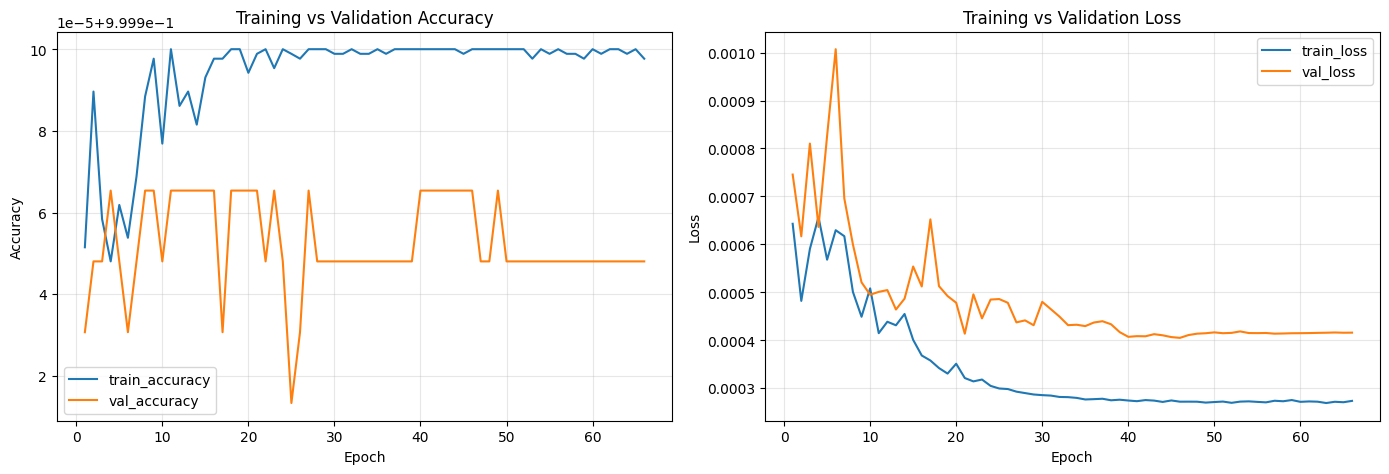

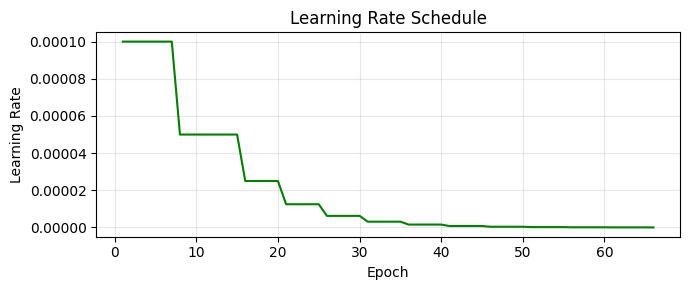

val_loss=0.0004, val_acc=1.0000
              precision    recall  f1-score   support

          你好       1.00      1.00      1.00       375
          學校       1.00      1.00      1.00       376
          同學       1.00      1.00      1.00       367
         屋企人       1.00      1.00      1.00       370
          鐘意       1.00      1.00      1.00       357
         唔鐘意       1.00      1.00      1.00       373
          點解       1.00      1.00      1.00       371
          彩虹       1.00      1.00      1.00       367
          謝謝       1.00      1.00      1.00       352
          等等       1.00      1.00      1.00       371
         對不起       1.00      1.00      1.00       370
          聾人       1.00      1.00      1.00       371
           我       1.00      1.00      1.00       370
          健聽       1.00      1.00      1.00       371
         ⁠手語       1.00      1.00      1.00       371
          現在       1.00      1.00      1.00       370
          高級       1.00      1.00      1.00      

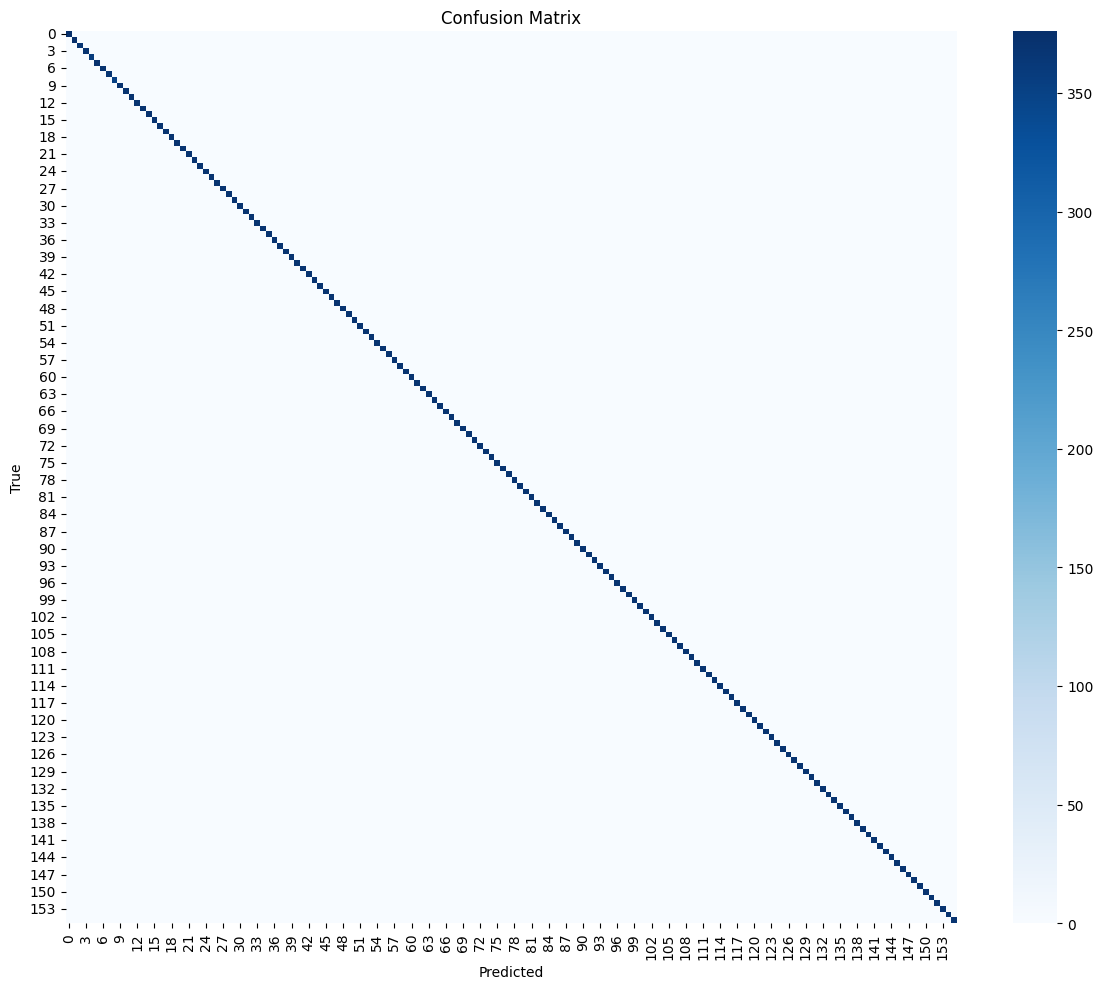


=== 最常混淆的類別對（>2 次）===

Keras model: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras


INFO:tensorflow:Assets written to: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel\assets


INFO:tensorflow:Assets written to: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel\assets


SavedModel: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel


Exception ignored in: <function Delegate.__del__ at 0x0000018AE77FA0E0>
Traceback (most recent call last):
  File "c:\GitHub\FYP-SignLanguage\cv_hands\.venv-train310\lib\site-packages\tensorflow\lite\python\interpreter.py", line 117, in __del__
    if self._library is not None:
AttributeError: 'Delegate' object has no attribute '_library'


TFLite: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.tflite
Flex delegate unavailable: Could not find module 'libtensorflowlite_flex.dll' (or one of its dependencies). Try using the full path with constructor syntax.

TFLite smoke test:
  Predicted: 132 (右)
  Actual:    132 (右)
  Confidence: 1.0000


In [4]:
# ── 訓練曲線 ──
if history is None:
    print('No training history (expand warmup only?). Skipping curves.')
else:
    hist = history.history
    epochs_range = range(1, len(hist['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, hist['accuracy'], label='train_accuracy')
    ax1.plot(epochs_range, hist['val_accuracy'], label='val_accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training vs Validation Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, hist['loss'], label='train_loss')
    ax2.plot(epochs_range, hist['val_loss'], label='val_loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training vs Validation Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    lr_key = 'lr' if 'lr' in hist else ('learning_rate' if 'learning_rate' in hist else None)
    if lr_key:
        fig2, ax3 = plt.subplots(figsize=(7, 3))
        ax3.plot(epochs_range, hist[lr_key], color='green')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_title('Learning Rate Schedule')
        ax3.grid(alpha=0.3)
        fig2.tight_layout()

    fig.tight_layout()
    plt.show()

# ── 評估 ──
val_loss, val_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

# ── 混淆矩陣 ──
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ── 列出最常混淆的類別對 ──
print('\n=== 最常混淆的類別對（>2 次）===')
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 2:
            print(f"  '{labels[i]}' → '{labels[j]}': {cm[i][j]} 次")

# ── 匯出 .keras / SavedModel / TFLite ──
# .keras（checkpoint 期間只存 weights，這裡輸出完整模型）
model.save(str(MODEL_SAVE_PATH))
print(f'\nKeras model: {MODEL_SAVE_PATH}')

# SavedModel
os.makedirs(str(SAVED_MODEL_DIR), exist_ok=True)
model.save(str(SAVED_MODEL_DIR), include_optimizer=False)
print(f'SavedModel: {SAVED_MODEL_DIR}')

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open(str(TFLITE_SAVE_PATH), 'wb') as f:
    f.write(tflite_model)
print(f'TFLite: {TFLITE_SAVE_PATH}')

# ── TFLite 推論 Smoke Test ──
from tensorflow.lite.python.interpreter import load_delegate
flex_lib = {
    'Windows': 'libtensorflowlite_flex.dll',
    'Linux': 'libtensorflowlite_flex.so',
    'Darwin': 'libtensorflowlite_flex.dylib'
}.get(platform.system(), 'libtensorflowlite_flex.so')

try:
    delegate = load_delegate(flex_lib)
    interpreter = tf.lite.Interpreter(model_path=str(TFLITE_SAVE_PATH), experimental_delegates=[delegate])
    print('Using flex delegate:', flex_lib)
except Exception as e:
    print('Flex delegate unavailable:', e)
    interpreter = tf.lite.Interpreter(model_path=str(TFLITE_SAVE_PATH))

interpreter.allocate_tensors()
input_detail = interpreter.get_input_details()[0]
output_detail = interpreter.get_output_details()[0]
interpreter.set_tensor(input_detail['index'], X_test[:1].astype(np.float32))
interpreter.invoke()
pred = interpreter.get_tensor(output_detail['index'])
pred_idx = int(np.argmax(pred, axis=1)[0])
true_idx = int(y_test[0])
print(f'\nTFLite smoke test:')
print(f'  Predicted: {pred_idx} ({labels[pred_idx] if pred_idx < len(labels) else "N/A"})')
print(f'  Actual:    {true_idx} ({labels[true_idx] if true_idx < len(labels) else "N/A"})')
print(f'  Confidence: {float(np.max(pred)):.4f}')

## 第 6 格在做什麼？（可選 5-fold 驗證）

這一格定義 `run_stratified_kfold(...)`，不會自動執行。

用途：
- 降低單次 train/test split 的偶然性
- 取得更穩定的平均準確率與標準差

建議：
- 先用 `n_splits=3, epochs=10` 快速測試
- 再跑正式 `n_splits=5, epochs=40` 產出最終結果

In [5]:
from sklearn.model_selection import StratifiedKFold
import gc

# Optional: 5-fold cross validation (time-consuming)
def run_stratified_kfold(model_type='GRU', n_splits=5, epochs=40, batch_size=32, verbose=1):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_accs = []

    can_stream = 'make_batched_dataset' in globals()

    def _fit_once(m, x_tr, y_tr, x_va, y_va, bs, use_stream):
        if use_stream and can_stream:
            train_ds, train_steps = make_batched_dataset(x_tr, y_tr, bs, shuffle=True, seed=RANDOM_SEED)
            val_ds, val_steps = make_batched_dataset(x_va, y_va, bs, shuffle=False, seed=RANDOM_SEED)
            m.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=fold_callbacks,
                verbose=verbose
            )
        else:
            m.fit(
                x_tr.astype(np.float32),
                y_tr.astype(np.int32),
                validation_data=(x_va.astype(np.float32), y_va.astype(np.int32)),
                epochs=epochs,
                batch_size=bs,
                callbacks=fold_callbacks,
                verbose=verbose
            )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_dataset, y_dataset), start=1):
        print(f'\n===== Fold {fold}/{n_splits} =====')

        # 每個 fold 先清一次，避免前一 fold 圖/張量殘留
        tf.keras.backend.clear_session()
        gc.collect()

        x_tr, x_va = X_dataset[train_idx], X_dataset[val_idx]
        y_tr, y_va = y_dataset[train_idx], y_dataset[val_idx]
        print('Train shape:', x_tr.shape, 'Val shape:', x_va.shape)

        m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
        m.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        fold_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                min_delta=1e-6,
                restore_best_weights=True
            )
        ]

        use_stream = can_stream
        trained = False

        try:
            _fit_once(m, x_tr, y_tr, x_va, y_va, batch_size, use_stream)
            trained = True
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as e:
            print(f'GPU failed on fold {fold}: {e}')

            retry_bs_list = [max(8, batch_size // 2), 8]
            retry_bs_list = list(dict.fromkeys(retry_bs_list))

            for retry_bs in retry_bs_list:
                try:
                    print(f'Retrying on GPU with batch_size={retry_bs}, stream={use_stream} ...')
                    tf.keras.backend.clear_session()
                    gc.collect()

                    m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
                    m.compile(
                        optimizer=tf.keras.optimizers.Adam(1e-3),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy']
                    )

                    _fit_once(m, x_tr, y_tr, x_va, y_va, retry_bs, use_stream)
                    trained = True
                    print(f'GPU retry succeeded on fold {fold} with batch_size={retry_bs}.')
                    break
                except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as retry_e:
                    print(f'GPU retry failed at batch_size={retry_bs}: {retry_e}')

            if not trained:
                print('Retrying this fold on CPU with smaller batch size...')
                tf.keras.backend.clear_session()
                gc.collect()

                cpu_bs = max(8, batch_size // 2)
                m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
                m.compile(
                    optimizer=tf.keras.optimizers.Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )

                with tf.device('/CPU:0'):
                    _fit_once(m, x_tr, y_tr, x_va, y_va, cpu_bs, use_stream=False)

        _, acc = m.evaluate(x_va.astype(np.float32), y_va.astype(np.int32), verbose=0)
        fold_accs.append(acc)
        print(f'Fold {fold} accuracy: {acc:.4f}')

        # fold 結束立即釋放
        del m, x_tr, x_va, y_tr, y_va
        tf.keras.backend.clear_session()
        gc.collect()

    print(f'\nMean ± Std = {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')
    return fold_accs

# 使用方式（建議先小規模測試）:
fold_accs = run_stratified_kfold(model_type=MODEL_TYPE, n_splits=5, epochs=40, batch_size=32, verbose=1)


===== Fold 1/5 =====
Train shape: (184652, 25, 80) Val shape: (46164, 25, 80)
Epoch 1/40
5771/5771 [==============================] - 70s 12ms/step - loss: 0.3713 - accuracy: 0.9199 - val_loss: 0.1110 - val_accuracy: 0.9875
Epoch 2/40
5771/5771 [==============================] - 69s 12ms/step - loss: 0.1303 - accuracy: 0.9835 - val_loss: 0.1044 - val_accuracy: 0.9901
Epoch 3/40
5771/5771 [==============================] - 68s 12ms/step - loss: 0.1133 - accuracy: 0.9875 - val_loss: 0.0762 - val_accuracy: 0.9976
Epoch 4/40
5771/5771 [==============================] - 67s 12ms/step - loss: 0.1010 - accuracy: 0.9900 - val_loss: 0.1001 - val_accuracy: 0.9910
Epoch 5/40
5771/5771 [==============================] - 68s 12ms/step - loss: 0.0890 - accuracy: 0.9916 - val_loss: 0.0608 - val_accuracy: 0.9977
Epoch 6/40
5771/5771 [==============================] - 67s 12ms/step - loss: 0.0802 - accuracy: 0.9925 - val_loss: 0.0568 - val_accuracy: 0.9979
Epoch 7/40
5771/5771 [=======================